In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2


In [3]:
fontsize=18

In [4]:
def read_data(sim_dir):
    #sim_data1 = np.loadtxt(f"{sim_dir}/sfr-halomass_central.txt")
    sim_data1 = np.loadtxt(f"{sim_dir}/sfr-halomass_sum.txt")

    mhalo_sim1 = sim_data1[:,0]
    sfr_sim1 = sim_data1[:,4]

    sim_data2 = np.loadtxt(f"{sim_dir}/sfr-cent_0sfr.txt")

    mhalo_sim2 = sim_data2[:,0]
    sfr_sim2 = sim_data2[:,4]

    mhalo_sim3 = np.concatenate((mhalo_sim1,np.round(mhalo_sim2,4)))
    sfr_sim3 = np.concatenate((sfr_sim1,sfr_sim2))
    return mhalo_sim3, sfr_sim3

In [5]:
tng_dir = "/cosma7/data/dp004/dc-zhan5/TNG/snap40/SubhaloFlag_all/mvir"
mhalo_tng, sfr_tng = read_data(tng_dir)


In [6]:
logM = 12.3
mask = (mhalo_tng > logM) & (mhalo_tng < logM + 0.1)

In [7]:
sfr1 = np.where(sfr_tng[mask] == -np.inf, -3.5, sfr_tng[mask])

In [8]:
logM = 11.3
mask = (mhalo_tng > logM ) & (mhalo_tng < logM + 0.1)
sfr2 = np.where(sfr_tng[mask] == -np.inf, -3.5, sfr_tng[mask])

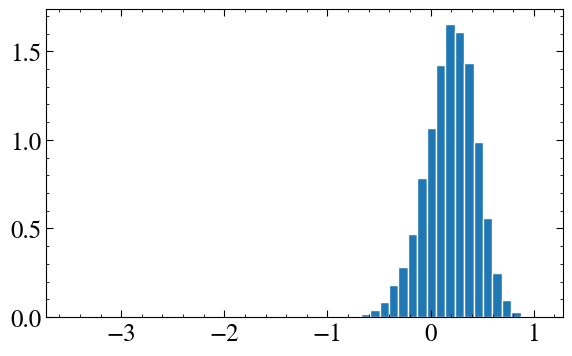

In [9]:
#plt.hist(sfr1, bins=50, density=True)
fig, ax = plt.subplots()

N, bins, patches = ax.hist(sfr2, bins=50, edgecolor='white', linewidth=1, density=True)
for i in range(0,1):
    patches[i].set_facecolor('grey')

<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1402430/1990698765.py:15: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')


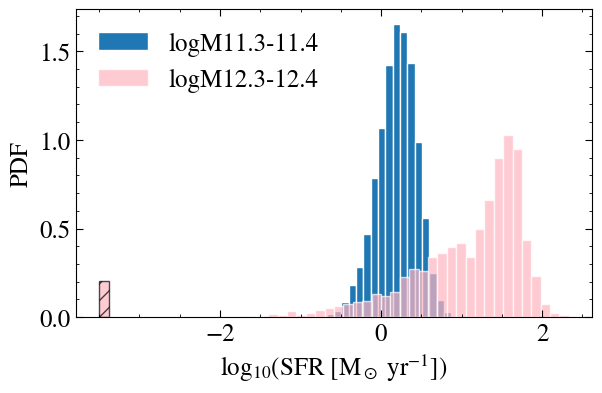

In [11]:
#plt.hist(sfr1, bins=50, density=True)
fig, ax = plt.subplots()



N, bins, patches = ax.hist(sfr2, bins=50, edgecolor='white', linewidth=1, density=True, label=r"logM11.3-11.4")
N, bins, patches = ax.hist(sfr1, bins=50, edgecolor='white', linewidth=1, density=True, alpha=0.7, color="lightpink", label=r"logM12.3-12.4")
plt.legend()

for i in range(0,1):
    patches[i].set_hatch("//")
    patches[i].set_edgecolor("black")
    
    
ax.set_xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])') 
ax.set_ylabel("PDF")
#plt.savefig("../figures/sfr_dist_11.3,12.3.pdf", format="pdf", bbox_inches="tight")


Running median

In [25]:

def running_percentiles(xdata, ydata, window_size, percentiles=[50], dx=0.1):
    # Calculate the running standard deviation
    not_inf = xdata > 5
    xdata = xdata[not_inf]
    ydata = ydata[not_inf]
    #print(min(xdata))
    nbins = int((max(xdata) - min(xdata))/dx)
    
    
    bin_first = min(xdata) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    
    running_percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        if i < window_size - 1:
            running_percentile_arr[i] = np.nan  # Not enough data points for the window
        else:   
            for ip, percentile in enumerate(percentiles):
                running_percentile_arr[ip][i] = np.percentile(ydata[bin_mask], q=percentile)
            bin_cents[i] = np.median(xdata[bin_mask])
    return bin_cents, running_percentile_arr



In [18]:
def running_fraction(xdata, ydata, window_size, lower_lim = -3, dx=0.1):
    # Calculate the running standard deviation
    
    nbins = int((max(xdata) - min(xdata))/dx)
    
    bin_first = min(xdata) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    running_frac_arr = np.zeros_like(bins, dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        lim_mask = ydata[bin_mask] < lower_lim
        if i < window_size - 1:
            running_frac_arr[i] = np.nan  # Not enough data points for the window
        else:   
            running_frac_arr[i] = np.sum(lim_mask)/np.sum(bin_mask)
            bin_cents[i] = np.median(xdata[bin_mask])
    return bin_cents, running_frac_arr



In [10]:
percentiles_list = [10, 25, 50, 75, 90]
window_size=0.2
dlogM= 0.1

In [26]:
bin_cents_tng, medians_tng = running_percentiles(mhalo_tng, sfr_tng, window_size, percentiles=[50], dx=dlogM)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above


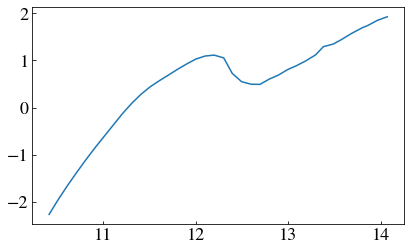

In [28]:
plt.plot(bin_cents_tng, medians_tng[0])

In [44]:

def running_std(xdata, ydata, window_size, percentiles=[50], dx=0.1, half=False):
    # Calculate the running standard deviation
    not_inf = xdata > 5
    xdata = xdata[not_inf]
    ydata = ydata[not_inf]
    #print(min(xdata))
    nbins = int((max(xdata) - min(xdata))/dx)
    
    
    bin_first = min(xdata) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    
    running_percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
    running_std_arr = np.zeros((len(percentiles),nbins), dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        if i < window_size - 1:
            running_percentile_arr[i] = np.nan  # Not enough data points for the window
        else:   
            for ip, percentile in enumerate(percentiles):
                percentile = np.percentile(ydata[bin_mask], q=percentile)
                running_percentile_arr[ip][i] = percentile
            bin_cents[i] = np.median(xdata[bin_mask])
        if half is False:
            std = np.std(ydata[bin_mask])
            running_std_arr[ip][i] = std
        elif half == "above":
            above_mask = ydata[bin_mask] > percentile
            diff = ydata[bin_mask][above_mask] - percentile
            new_below_data = percentile - diff
            new_data = np.concatenate((ydata[bin_mask][above_mask], new_below_data))
            std = np.std(new_data)
            running_std_arr[ip][i] = std
    return bin_cents, running_percentile_arr, running_std_arr



In [49]:
bin_cents_tng, medians_tng = running_percentiles(mhalo_tng, sfr_tng, window_size, percentiles=[50], dx=dlogM)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above


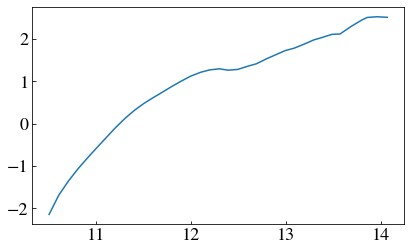

In [50]:
plt.plot(bin_cents_tng, medians_tng[0])

In [51]:
bin_cents_tng, medians_tng,std = running_std(mhalo_tng, sfr_tng, window_size, percentiles=[50], dx=dlogM, half="above")


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:202: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


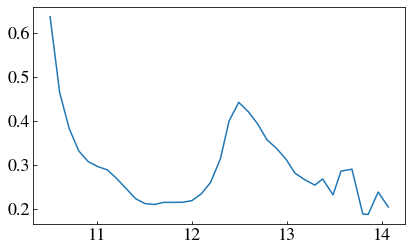

In [52]:
plt.plot(bin_cents_tng, std[0])

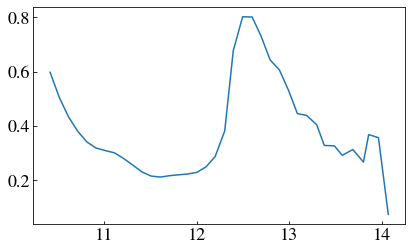

In [46]:
plt.plot(bin_cents_tng, std[0])

In [64]:
color_list_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [11]:
color_list = ["blue", color_list_default[1], "darkorchid"]

In [65]:
print(color_list_default[1])

#ff7f0e


In [37]:
max(mhalo_tng)

13.670969486236572

In [13]:
sfr_tng_changed = np.where(np.isinf(sfr_tng), -4, sfr_tng)

In [20]:
min(sfr_tng)

-inf

(7.739553356170655, 13.953417873382568)

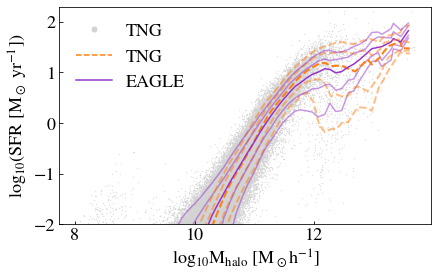

In [19]:
plt.scatter(mhalo_tng[sfr_tng>-4], sfr_tng[sfr_tng>-4], s=0.1, color="lightgrey", label="TNG")

#tng_scatter = plt.scatter(mhalo_tng, sfr_tng, s=0.1, color="lightgrey", label=TNG)
for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    plt.plot(bin_cents_tng, percentiles_tng[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
    plt.plot(bin_cents_eagle, percentiles_eagle[i], color=color_list[2],alpha = alpha)

tng_scatter = Line2D([],[], marker=".", linewidth=0, markersize=10, color="lightgrey", label="TNG")
tng = Line2D([],[], linestyle="dashed", color=color_list[1], label="TNG")
eagle = Line2D([],[], linestyle="solid", color=color_list[2], label="EAGLE")
plt.legend(handles=[tng_scatter, tng,eagle])
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylim(-2,2.3)
plt.xlim()


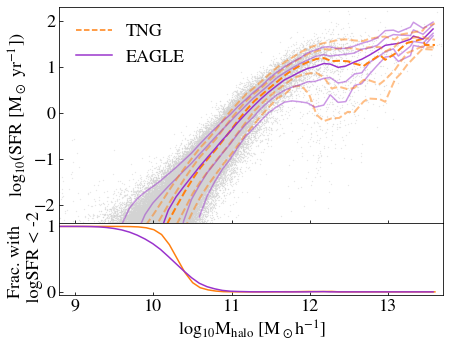

In [23]:

figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))
tng_scatter = plt.scatter(mhalo_tng[sfr_tng>-4], sfr_tng[sfr_tng>-4], s=0.05, color="lightgrey", label="TNG")

for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    plt.plot(bin_cents_tng, percentiles_tng[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth=2)
    plt.plot(bin_cents_eagle, percentiles_eagle[i], color=color_list[2],alpha = alpha)

tng = Line2D([],[], linestyle="dashed", color=color_list[1], label="TNG")
eagle = Line2D([],[], linestyle="solid", color=color_list[2], label="EAGLE")
plt.legend(handles=[tng,eagle])
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylim(-2.4,2.3)

frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

plt.plot(bin_cents_frac_tng, tng_frac, color=color_list[1], label="TNG")
plt.plot(bin_cents_frac_eagle, eagle_frac, color=color_list[2], label="EAGLE")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel("Frac. with \n logSFR < -2")
plt.xlim(8.8, 13.7)

plt.savefig("tng_eagle_percentiles_100.png", format="png", bbox_inches="tight", dpi=300)

In [22]:
def dist_from_median(percentiles_data):
    diff_list = []
    for percentile in percentiles_data:
        diff = percentile - percentiles_data[2]
        diff_list.append(diff)
    return diff_list

In [23]:
diff_tng = dist_from_median(percentiles_tng)
diff_eagle = dist_from_median(percentiles_eagle)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in subtract
  after removing the cwd from sys.path.


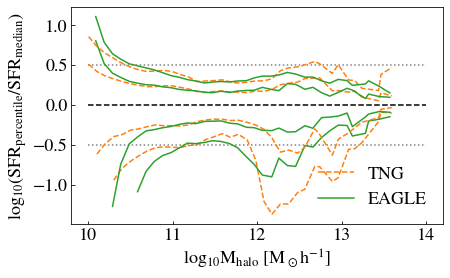

In [26]:
plt.plot([10,14], [0,0], linestyle="dashed", color="black")
plt.plot([10,14], [-0.5,-0.5], linestyle="dotted", color="grey")
plt.plot([10,14], [0.5,0.5], linestyle="dotted", color="grey")
for i in range(len(percentiles_list)):
    if i != 2:
        plt.plot(bin_cents_tng, diff_tng[i], linestyle="dashed", color=color_list[1])
        plt.plot(bin_cents_eagle, diff_eagle[i], color=color_list[2])
tng = Line2D([],[], linestyle="dashed", color=color_list[1], label="TNG")
eagle = Line2D([],[], linestyle="solid", color=color_list[2], label="EAGLE")
plt.legend(handles=[tng,eagle])
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r'log$_{10}$(SFR$_{\rm percentile}$/SFR$_{\rm median}$)')
#plt.savefig("dist_from_median_0.5_100.pdf", format="pdf", bbox_inches="tight")

In [ ]:
sfr_eagle_changed = np.where(np.isinf(sfr_eagle), -4, sfr_eagle)

In [21]:
sfr_eagle_changed = np.where(np.isinf(sfr_eagle), -4, sfr_eagle)

In [15]:
bin_cents_frac_tng, tng_frac = running_fraction(mhalo_tng, sfr_tng, window_size,lower_lim = -2, dx=dlogM)

In [16]:
bin_cents_frac_eagle, eagle_frac = running_fraction(mhalo_eagle, sfr_eagle, window_size,lower_lim = -2, dx=dlogM)

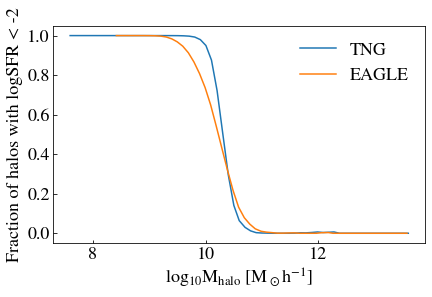

In [17]:
plt.plot(bin_cents_frac_tng, tng_frac, label="TNG")
plt.plot(bin_cents_frac_eagle, eagle_frac, label="EAGLE")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"Fraction of halos with logSFR < -2")
plt.legend()

(0.9, 1.0)

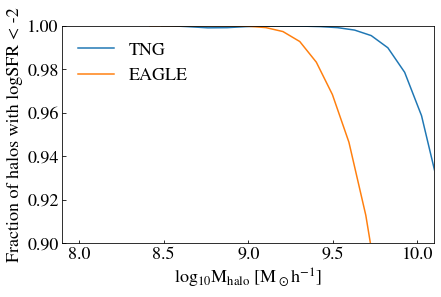

In [37]:
plt.plot(bin_cents_frac_tng, tng_frac, label="TNG")
plt.plot(bin_cents_frac_eagle, eagle_frac, label="EAGLE")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"Fraction of halos with logSFR < -2")
plt.legend()
plt.xlim(7.9,10.1)
plt.ylim(0.9,1)

In [37]:
bin_cents_frac_tng_ssfr, tng_frac_ssfr = running_fraction(mhalo_tng, np.log10(10**sfr_tng/10**mhalo_tng), window_size,lower_lim = -12, dx=dlogM)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [38]:
bin_cents_frac_eagle_ssfr, eagle_frac_ssfr = running_fraction(mhalo_eagle, np.log10(10**sfr_eagle/10**mhalo_eagle), window_size,lower_lim = -12, dx=dlogM)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


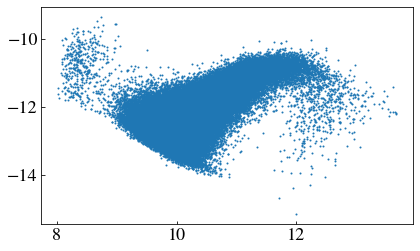

In [18]:
plt.scatter(mhalo_tng, np.log10(10**sfr_tng/10**mhalo_tng), s=1)

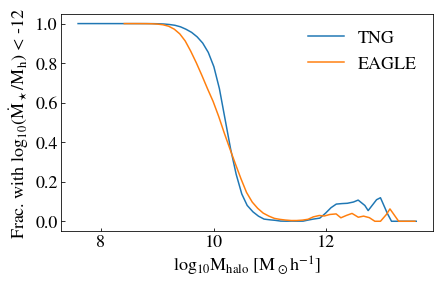

In [35]:
plt.plot(bin_cents_frac_tng_ssfr, tng_frac_ssfr, label="TNG")
plt.plot(bin_cents_frac_eagle_ssfr, eagle_frac_ssfr, label="EAGLE")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"Frac. with $\rm log_{10}( \dot{M}_\star / M_h$) < -12")
plt.legend()

In [14]:
ssfr_tng = np.log10(10**sfr_tng/10**mhalo_tng)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [15]:
ssfr_eagle = np.log10(10**sfr_eagle/10**mhalo_eagle)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [16]:
bin_cents_tng_ssfr, percentiles_tng_ssfr = running_percentiles(mhalo_tng, ssfr_tng, window_size, percentiles=percentiles_list, dx=dlogM)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above


In [17]:
bin_cents_eagle_ssfr, percentiles_eagle_ssfr = running_percentiles(mhalo_eagle, ssfr_eagle, window_size, percentiles=percentiles_list, dx=dlogM)


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above


In [63]:

figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))
tng_scatter = plt.scatter(mhalo_tng[ssfr_tng>-15],ssfr_tng[ssfr_tng>-15] , s=0.05, color="lightgrey", label="TNG")

for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    plt.plot(bin_cents_tng_ssfr, percentiles_tng_ssfr[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth=2)
    plt.plot(bin_cents_eagle_ssfr, percentiles_eagle_ssfr[i], color=color_list[2],alpha = alpha)

tng = Line2D([],[], linestyle="dashed", color=color_list[1], label="TNG")
eagle = Line2D([],[], linestyle="solid", color=color_list[2], label="EAGLE")
plt.legend(handles=[tng,eagle])
plt.xlabel(r"log$_{10}$M$_{\rm FOF}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r'$\rm log_{10}( \dot{M}_\star / M_{FOF}$) ')
plt.ylim(-14.7,-9.3)

frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

plt.plot(bin_cents_frac_tng_ssfr, tng_frac_ssfr, color=color_list[1], label="TNG")
plt.plot(bin_cents_frac_eagle_ssfr, eagle_frac_ssfr, color=color_list[2], label="EAGLE")
plt.xlabel(r"log$_{10}$M$_{\rm FOF}$ [M$_\odot$h$^{-1}$]")
plt.ylabel("Frac. with" + "\n" +  r"$\rm \dot{M}_\star / M_{FOF} < 10^{-12}$", fontsize = 16)
plt.xlim(8.8, 13.7)
#plt.show()

plt.savefig("tng_eagle_percentiles_100_ssfr.png", format="png", bbox_inches="tight", dpi=300)
plt.clf()

<Figure size 480x360 with 0 Axes>

In [31]:
min(ssfr_tng[ssfr_tng>-15])

-14.676020264720153